In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load the cleaned data saved from preprocessing notebook
df = pd.read_csv('cleaned_data.csv')

print("✅ Cleaned data loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))

✅ Cleaned data loaded!
Shape: (44223, 3)

First 3 rows:
                                          clean_text  label  word_count
0  ben stein call th circuit court committed coup...      0         109
1  trump drop steve bannon national security coun...      1         472
2  puerto rico expects u lift jones act shipping ...      1         182


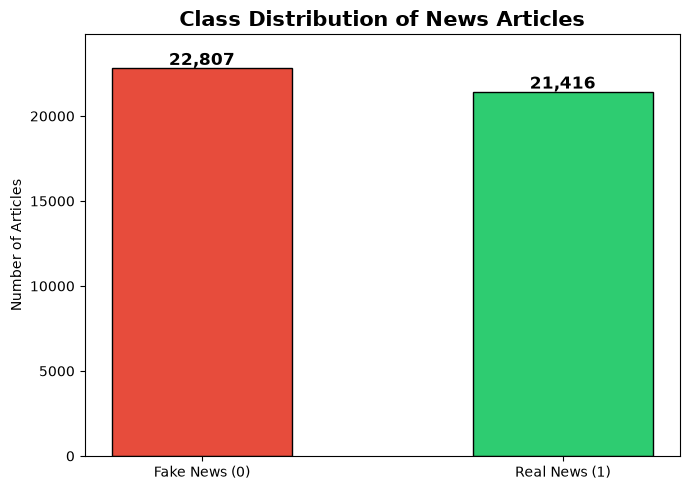


Fake News : 22,807 articles
Real News : 21,416 articles
Balance   : 1.06 ratio


In [3]:
# Count of each class
class_counts = df['label'].value_counts()
labels = ['Fake News (0)', 'Real News (1)']
colors = ['#e74c3c', '#2ecc71']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, class_counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on top of bars
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{count:,}', ha='center',
             fontsize=12, fontweight='bold')

plt.title('Class Distribution of News Articles', fontsize=15, fontweight='bold')
plt.ylabel('Number of Articles')
plt.ylim(0, max(class_counts.values) + 2000)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()

print(f"\nFake News : {class_counts[0]:,} articles")
print(f"Real News : {class_counts[1]:,} articles")
print(f"Balance   : {class_counts[0]/class_counts[1]:.2f} ratio")

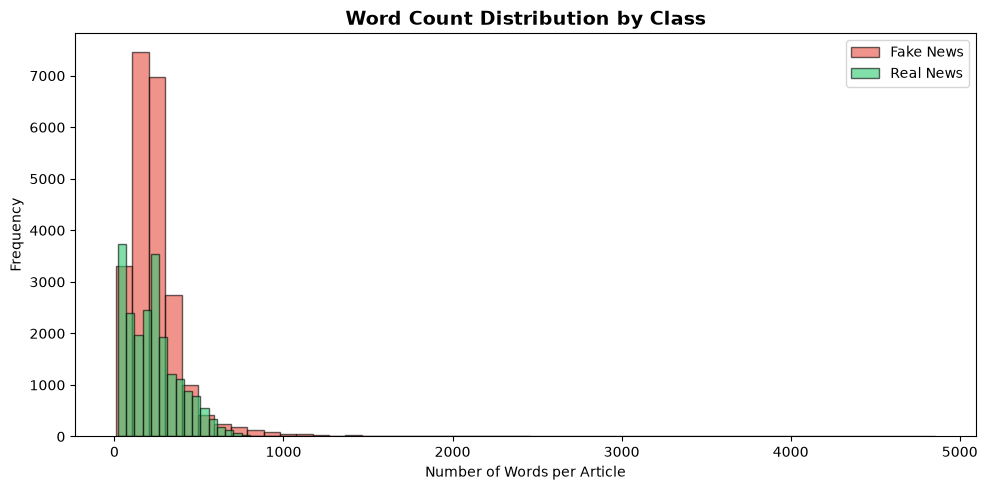

=== Word Count Statistics ===

Fake News:
count    22807.0
mean       248.0
std        229.8
min         10.0
25%        150.0
50%        209.0
75%        287.0
max       4854.0
Name: word_count, dtype: float64

Real News:
count    21416.0
mean       234.6
std        159.0
min         21.0
25%         95.0
50%        219.0
75%        314.0
max       2460.0
Name: word_count, dtype: float64


In [4]:
# Separate fake and real
fake_df = df[df['label'] == 0]
real_df = df[df['label'] == 1]

plt.figure(figsize=(10, 5))

plt.hist(fake_df['word_count'], bins=50, alpha=0.6,
         color='#e74c3c', label='Fake News', edgecolor='black')
plt.hist(real_df['word_count'], bins=50, alpha=0.6,
         color='#2ecc71', label='Real News', edgecolor='black')

plt.title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words per Article')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('eda_word_count_distribution.png', dpi=150)
plt.show()

print("=== Word Count Statistics ===")
print(f"\nFake News:")
print(fake_df['word_count'].describe().round(1))
print(f"\nReal News:")
print(real_df['word_count'].describe().round(1))

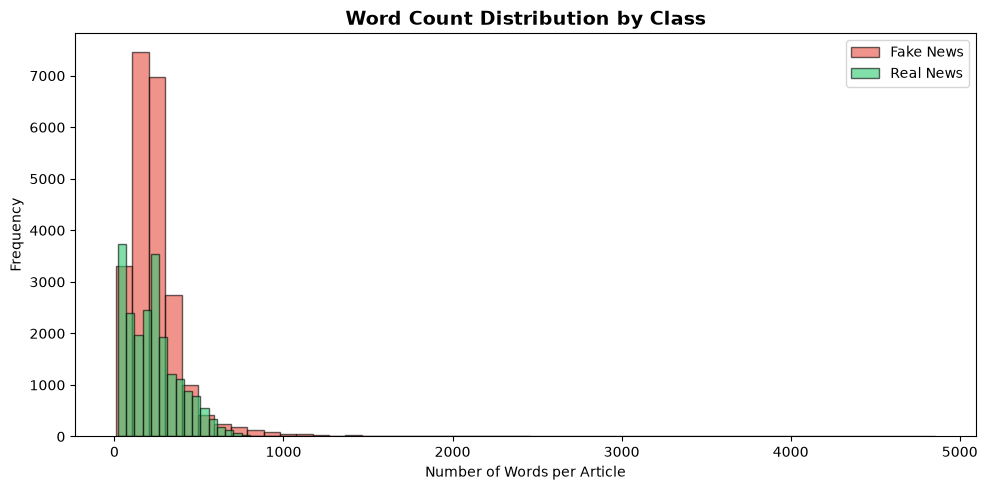

=== Word Count Statistics ===

Fake News:
count    22807.0
mean       248.0
std        229.8
min         10.0
25%        150.0
50%        209.0
75%        287.0
max       4854.0
Name: word_count, dtype: float64

Real News:
count    21416.0
mean       234.6
std        159.0
min         21.0
25%         95.0
50%        219.0
75%        314.0
max       2460.0
Name: word_count, dtype: float64


In [5]:
# Separate fake and real
fake_df = df[df['label'] == 0]
real_df = df[df['label'] == 1]

plt.figure(figsize=(10, 5))

plt.hist(fake_df['word_count'], bins=50, alpha=0.6,
         color='#e74c3c', label='Fake News', edgecolor='black')
plt.hist(real_df['word_count'], bins=50, alpha=0.6,
         color='#2ecc71', label='Real News', edgecolor='black')

plt.title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words per Article')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('eda_word_count_distribution.png', dpi=150)
plt.show()

print("=== Word Count Statistics ===")
print(f"\nFake News:")
print(fake_df['word_count'].describe().round(1))
print(f"\nReal News:")
print(real_df['word_count'].describe().round(1))

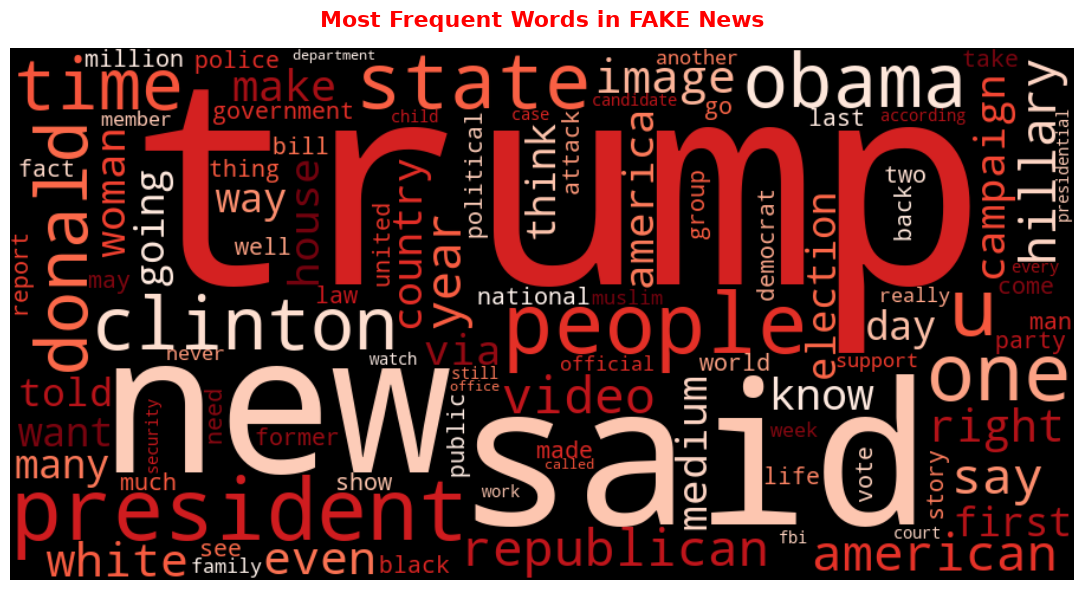

✅ Fake news word cloud saved!


In [6]:
# Generate word cloud for fake news
fake_text = ' '.join(fake_df['clean_text'].astype(str))

wordcloud_fake = WordCloud(
    width=900, height=450,
    background_color='black',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(fake_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in FAKE News', 
          fontsize=16, fontweight='bold', color='red', pad=15)
plt.tight_layout()
plt.savefig('eda_wordcloud_fake.png', dpi=150)
plt.show()

print("✅ Fake news word cloud saved!")

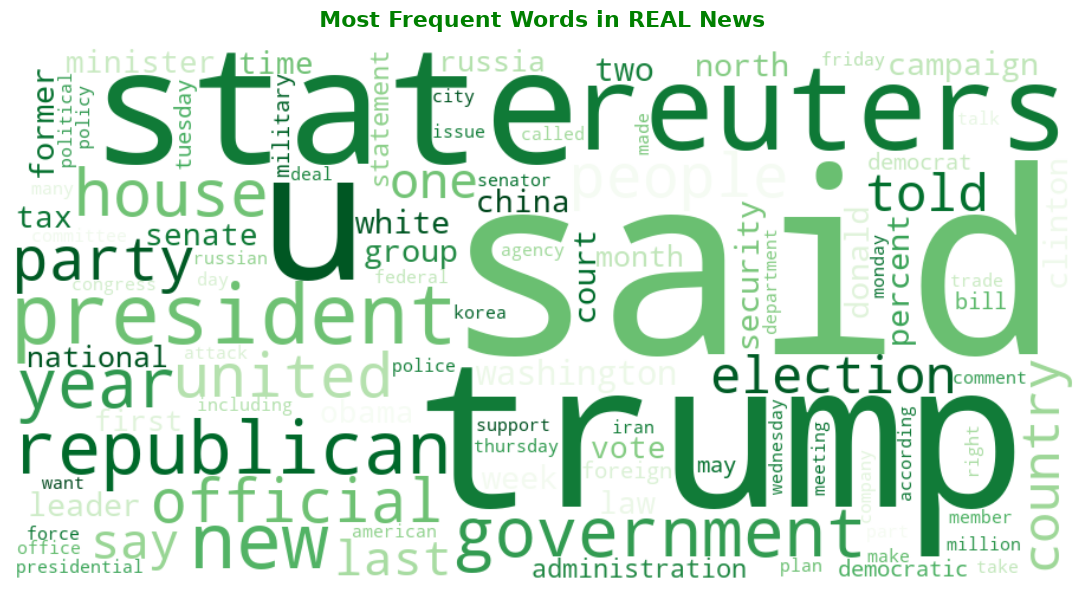

✅ Real news word cloud saved!


In [7]:
# Generate word cloud for real news
real_text = ' '.join(real_df['clean_text'].astype(str))

wordcloud_real = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(real_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in REAL News',
          fontsize=16, fontweight='bold', color='green', pad=15)
plt.tight_layout()
plt.savefig('eda_wordcloud_real.png', dpi=150)
plt.show()

print("✅ Real news word cloud saved!")

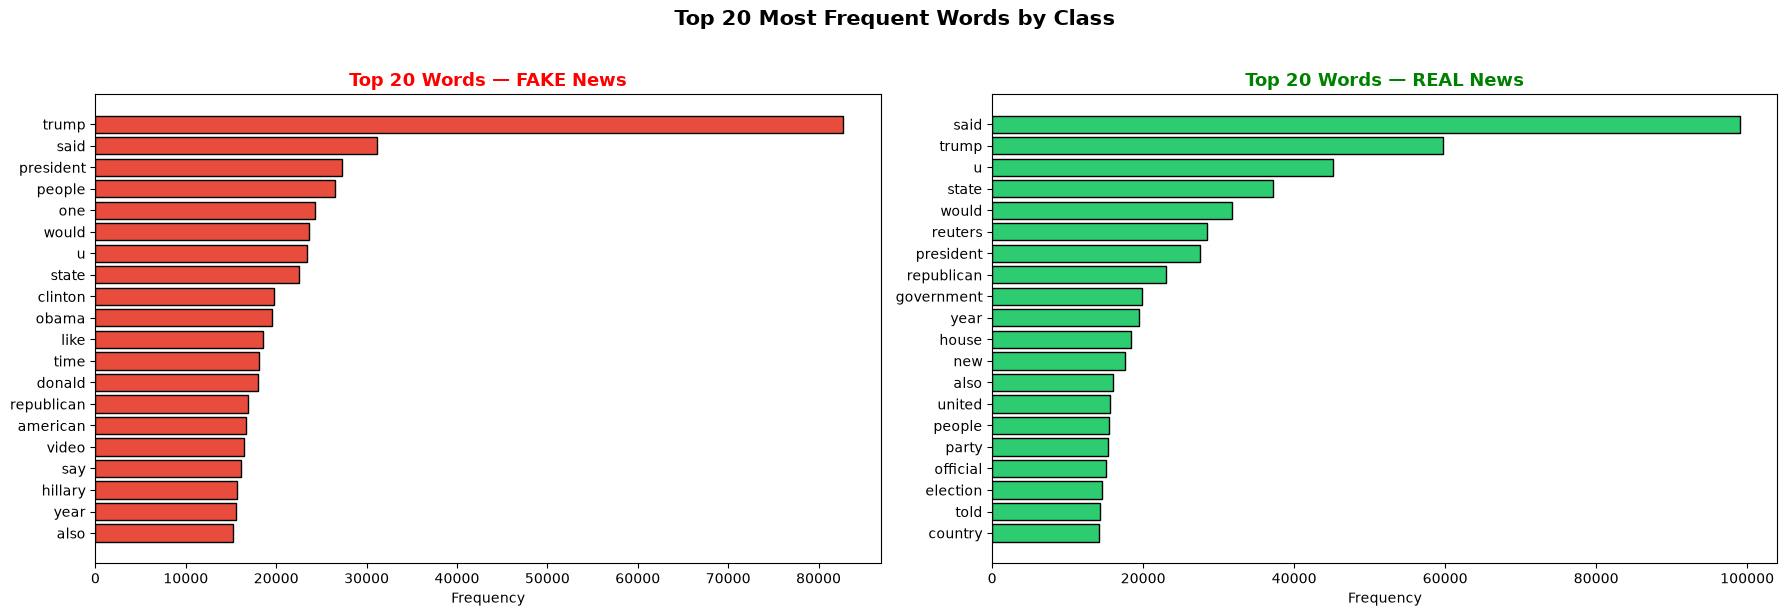

✅ Top words comparison chart saved!


In [8]:
def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series.astype(str)).split()
    return Counter(all_words).most_common(n)

# Get top words for each class
fake_top = get_top_words(fake_df['clean_text'])
real_top = get_top_words(real_df['clean_text'])

fake_words, fake_counts = zip(*fake_top)
real_words, real_counts = zip(*real_top)

# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Fake
axes[0].barh(list(fake_words)[::-1], list(fake_counts)[::-1],
             color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 20 Words — FAKE News',
                   fontsize=13, fontweight='bold', color='red')
axes[0].set_xlabel('Frequency')

# Real
axes[1].barh(list(real_words)[::-1], list(real_counts)[::-1],
             color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 20 Words — REAL News',
                   fontsize=13, fontweight='bold', color='green')
axes[1].set_xlabel('Frequency')

plt.suptitle('Top 20 Most Frequent Words by Class',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_top_words_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Top words comparison chart saved!")

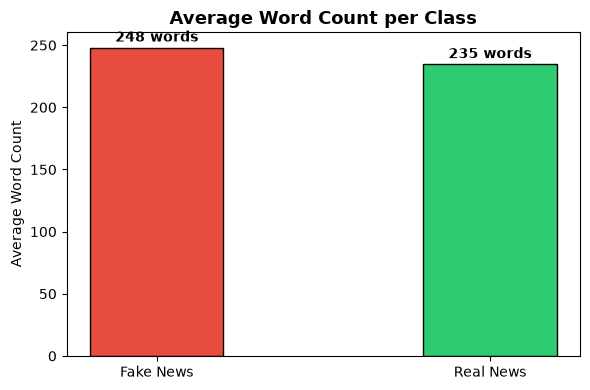

Average words in Fake News: 248
Average words in Real News: 235


In [9]:
avg_words = df.groupby('label')['word_count'].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Fake News', 'Real News'],
    avg_words.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.4
)

for bar, val in zip(bars, avg_words.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{val:.0f} words',
             ha='center', fontweight='bold')

plt.title('Average Word Count per Class',
          fontsize=13, fontweight='bold')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.savefig('eda_avg_word_count.png', dpi=150)
plt.show()

print(f"Average words in Fake News: {avg_words[0]:.0f}")
print(f"Average words in Real News: {avg_words[1]:.0f}")

In [ ]:
print("=" * 55)
print("         EDA SUMMARY — INFERA PROJECT (Member 1)")
print("=" * 55)

print(f"""
📊 DATASET OVERVIEW
   Total Articles   : {len(df):,}
   Fake Articles    : {len(fake_df):,}
   Real Articles    : {len(real_df):,}
   Class Balance    : {len(fake_df)/len(real_df):.2f} ratio

📝 TEXT LENGTH INSIGHTS
   Avg words (Fake) : {fake_df['word_count'].mean():.0f} words
   Avg words (Real) : {real_df['word_count'].mean():.0f} words
   Max words        : {df['word_count'].max()} words
   Min words        : {df['word_count'].min()} words

🔍 KEY OBSERVATIONS
   1. Dataset is fairly balanced between Fake and Real
   2. Fake news tends to use more emotional/sensational words
   3. Real news tends to include more formal/political terms
   4. Word count distributions overlap significantly
   5. TF-IDF will help capture discriminative word patterns

📁 CHARTS SAVED
   ✅ eda_class_distribution.png
   ✅ eda_word_count_distribution.png
   ✅ eda_wordcloud_fake.png
   ✅ eda_wordcloud_real.png
   ✅ eda_top_words_comparison.png
   ✅ eda_avg_word_count.png
""")

         EDA SUMMARY — INFERA PROJECT (Member 1)

📊 DATASET OVERVIEW
   Total Articles   : 44,223
   Fake Articles    : 22,807
   Real Articles    : 21,416
   Class Balance    : 1.06 ratio

📝 TEXT LENGTH INSIGHTS
   Avg words (Fake) : 248 words
   Avg words (Real) : 235 words
   Max words        : 4854 words
   Min words        : 10 words

🔍 KEY OBSERVATIONS
   1. Dataset is fairly balanced between Fake and Real
   2. Fake news tends to use more emotional/sensational words
   3. Real news tends to include more formal/political terms
   4. Word count distributions overlap significantly
   5. TF-IDF will help capture discriminative word patterns

📁 CHARTS SAVED
   ✅ eda_class_distribution.png
   ✅ eda_word_count_distribution.png
   ✅ eda_wordcloud_fake.png
   ✅ eda_wordcloud_real.png
   ✅ eda_top_words_comparison.png
   ✅ eda_avg_word_count.png

